# Notebook 2 — Feature Engineering

**Purpose:** Engineer suspicion signals from `player_features_last10` and produce
a scored, enriched dataset ready for ML classification in Notebook 3.

**Derived features:**
| Feature | Description |
|---|---|
| `accuracy_z_score` | z-score of `avg_accuracy` |
| `reaction_z_score` | z-score of `avg_reaction_time_ms`, **inverted** (lower ms = higher score) |
| `headshot_z_score` | z-score of `avg_headshot_rate` |
| `suspicion_score` | `accuracy_z + headshot_z - reaction_z` |
| `consistency_flag` | 1 if `stddev_accuracy < 0.05` AND `stddev_reaction_time_ms < 20` |

**Output:** `data/processed/player_features_engineered.csv` + PostgreSQL table `player_features_engineered`

## Cell 1 — Imports & DB Connection

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from scipy import stats

load_dotenv()

sns.set_theme(style="whitegrid", palette="muted")
FIGURES_DIR = Path("../reports/figures")
PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

engine = create_engine(os.environ["DATABASE_URL"])
print("Connected to PostgreSQL")

Connected to PostgreSQL


## Cell 2 — Load Data

In [2]:
with engine.connect() as conn:
    df = pd.read_sql(text("SELECT * FROM raw.player_features_last10"), conn)

print(f"Loaded {len(df):,} rows")
df.head(3)

Loaded 800 rows


,player_id,matches_played,avg_kills,avg_deaths,kd_ratio,avg_accuracy,stddev_accuracy,avg_headshot_rate,avg_reaction_time_ms,stddev_reaction_time_ms,avg_damage_dealt,cheater_flag
0,player_0000,10,6.30,5.90,1.0678,0.3031,0.106992,0.1974,257.01,40.5752,1133.3,0
1,player_0001,7,9.86,5.71,1.7250,0.2986,0.150293,0.2231,217.81,56.7221,1284.0,0
2,player_0002,10,10.50,6.80,1.5441,0.2679,0.091712,0.1357,211.44,27.9811,1353.9,0


## Cell 3 — Engineer Features

In [3]:
fe = df.copy()

# Z-scores
fe["accuracy_z_score"]  = stats.zscore(fe["avg_accuracy"],           nan_policy="omit")
fe["headshot_z_score"]  = stats.zscore(fe["avg_headshot_rate"],       nan_policy="omit")
# Reaction time: invert so higher z = more suspicious
fe["reaction_z_score"]  = -stats.zscore(fe["avg_reaction_time_ms"],   nan_policy="omit")

# Composite suspicion score
fe["suspicion_score"]   = (fe["accuracy_z_score"]
                           + fe["headshot_z_score"]
                           + fe["reaction_z_score"])

# Consistency flag: robotically consistent players (low stddev)
fe["consistency_flag"]  = (
    (fe["stddev_accuracy"] < 0.05) &
    (fe["stddev_reaction_time_ms"] < 20)
).astype(int)

print("New features added:",
      ["accuracy_z_score", "headshot_z_score", "reaction_z_score",
       "suspicion_score", "consistency_flag"])
fe[["player_id", "accuracy_z_score", "headshot_z_score",
    "reaction_z_score", "suspicion_score", "consistency_flag", "cheater_flag"]].describe().round(3)

New features added: ['accuracy_z_score', 'headshot_z_score', 'reaction_z_score', 'suspicion_score', 'consistency_flag']


,accuracy_z_score,headshot_z_score,reaction_z_score,suspicion_score,consistency_flag,cheater_flag
count,800.000,800.000,800.000,800.000,800.000,800.000
mean,-0.000,-0.000,-0.000,-0.000,0.001,0.050
std,1.001,1.001,1.001,2.867,0.035,0.218
min,-1.355,-1.024,-1.700,-2.752,0.000,0.000
25%,-0.429,-0.396,-0.520,-1.040,0.000,0.000
50%,-0.206,-0.210,-0.154,-0.598,0.000,0.000
75%,0.045,-0.011,0.174,-0.137,0.000,0.000
max,4.599,4.922,4.347,13.054,1.000,1.000


## Cell 4 — Top 20 Players by Suspicion Score

In [4]:
top20 = (
    fe
    .sort_values("suspicion_score", ascending=False)
    .head(20)[
        ["player_id", "avg_accuracy", "avg_headshot_rate",
         "avg_reaction_time_ms", "suspicion_score",
         "consistency_flag", "cheater_flag"]
    ]
    .reset_index(drop=True)
)
top20.index += 1
top20["suspicion_score"] = top20["suspicion_score"].round(3)

print("Top 20 players by suspicion_score:")
print(top20.to_string())

Top 20 players by suspicion_score:
      player_id  avg_accuracy  avg_headshot_rate  avg_reaction_time_ms  suspicion_score  consistency_flag  cheater_flag
1   player_0089        0.7663             0.6996                 82.70           13.054                 0             1
2   player_0095        0.7663             0.6933                 81.08           13.039                 0             1
3   player_0459        0.7247             0.7215                 77.22           12.997                 0             1
4   player_0604        0.7168             0.6766                 61.89           12.914                 0             1
5   player_0032        0.7396             0.6768                 72.58           12.844                 0             1
6   player_0142        0.7632             0.6437                 78.70           12.587                 0             1
7   player_0517        0.7300             0.6540                 70.81           12.571                 0             1
8   p

## Cell 5 — Suspicion Score Distribution

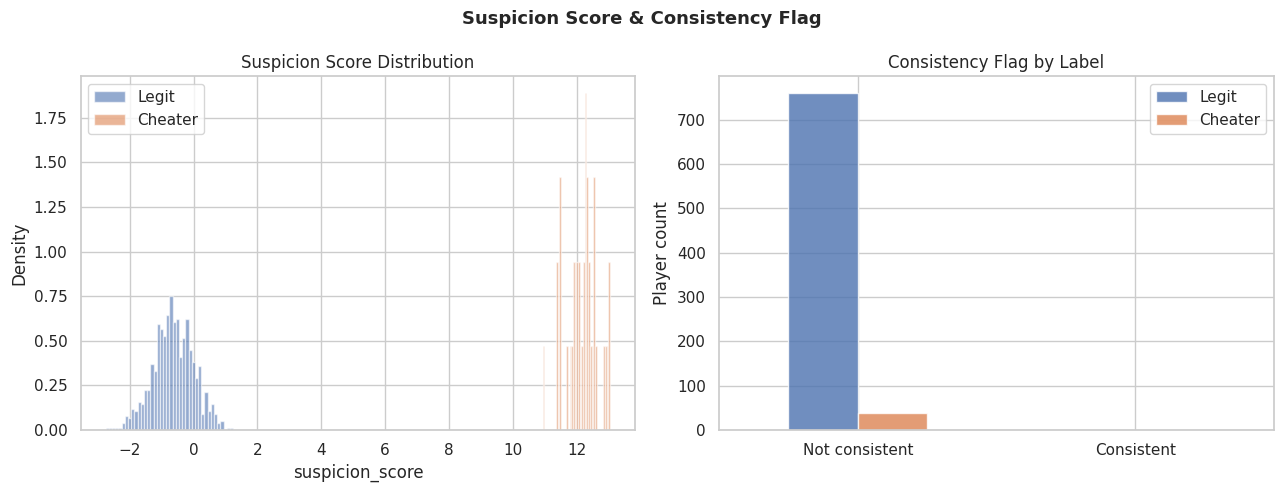

Saved 04_suspicion_score.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Suspicion Score & Consistency Flag", fontsize=13, fontweight="bold")

# --- Left: suspicion score histogram split by cheater_flag ---
labels = {0: "Legit", 1: "Cheater"}
colors = {0: "#4C72B0", 1: "#DD8452"}
ax = axes[0]
for flag in [0, 1]:
    subset = fe.loc[fe["cheater_flag"] == flag, "suspicion_score"]
    subset.plot.hist(
        ax=ax, bins=40, alpha=0.6,
        color=colors[flag], label=labels[flag], density=True
    )
ax.set_title("Suspicion Score Distribution")
ax.set_xlabel("suspicion_score")
ax.set_ylabel("Density")
ax.legend()

# --- Right: consistency_flag bar chart split by cheater_flag ---
ax2 = axes[1]
ct = pd.crosstab(fe["consistency_flag"], fe["cheater_flag"])
ct.columns = [labels[c] for c in ct.columns]
ct.index = ["Not consistent", "Consistent"]
ct.plot.bar(ax=ax2, color=[colors[0], colors[1]], alpha=0.8, rot=0)
ax2.set_title("Consistency Flag by Label")
ax2.set_xlabel("")
ax2.set_ylabel("Player count")
ax2.legend(title="")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "04_suspicion_score.png", dpi=150)
plt.show()
print("Saved 04_suspicion_score.png")

## Cell 6 — Export to CSV & PostgreSQL

In [6]:
csv_path = PROCESSED_DIR / "player_features_engineered.csv"
fe.to_csv(csv_path, index=False)
print(f"Saved CSV: {csv_path}  ({len(fe):,} rows)")

fe.to_sql(
    name="player_features_engineered",
    con=engine,
    schema="raw",
    if_exists="replace",
    index=False,
    method="multi",
    chunksize=500,
)

with engine.connect() as conn:
    n = conn.execute(
        text("SELECT COUNT(*) FROM raw.player_features_engineered")
    ).scalar()
print(f"Wrote {n:,} rows to raw.player_features_engineered")

Saved CSV: ../data/processed/player_features_engineered.csv  (800 rows)


Wrote 800 rows to raw.player_features_engineered
